In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from multiprocessing import Manager
from scipy.optimize import linear_sum_assignment
from tqdm.contrib.concurrent import process_map
import networkx as nx
import random
import heapq
import json
from copy import deepcopy
from utils import lineage_name_mapping, load_json, bidict
from zss import simple_distance, Node
from matplotlib import pyplot as plt
from typing import List, Tuple, Dict, Any
from functools import partial
from itertools import combinations

In [2]:
class LineageTree:
    """"
    A binary tree class representing a lineage tree.
    Each node will have a unique internal id starting from 0
    When a node is created and added to the tree, it will be assigned the size of the tree as its id.
    Children information is stored in children_list, where children_list[i] is a list of the internal ids of the children of node i.
    Parent information is stored in parent_list, where parent_list[i] is the internal id of the parent of node i. The root node's parent is -1.
    The size of the tree is stored in size.
    Each node also carry an interger value representing the lineage identity.
    The mapping from internal id to interger value is stored in list lineage_id_list, where lineage_id_list[i] is the interger value of node i.
    """
    def __init__(self, size=0):
        self.size = size
        self.children_list = [[]] * size
        self.parent_list = [-1] * size
        self.lineage_id_mapping = []
        self.reverse_lineage_id_mapping = {}
        self.root = -1
    
    def add_node(self, lineage_id, parent_id=-1):
        current_id = self.size
        self.lineage_id_mapping.append(lineage_id)
        self.reverse_lineage_id_mapping[lineage_id] = current_id
        self.children_list.append([])
        self.parent_list.append(parent_id)
        if parent_id != -1:
            self.children_list[parent_id].append(current_id)
        self.size += 1
        return current_id

    def __deepcopy__(self, memo=None):
        if memo is None:
            memo = {}
        new_tree = LineageTree(self.size)
        memo[id(self)] = new_tree
        new_tree.children_list = [children.copy() for children in self.children_list]
        new_tree.parent_list = self.parent_list.copy()
        new_tree.lineage_id_mapping = self.lineage_id_mapping.copy()
        new_tree.reverse_lineage_id_mapping = self.reverse_lineage_id_mapping.copy()
        new_tree.root = self.root
        return new_tree


In [3]:
lineage_data = load_json('./data/cell_lineage.json')
lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0)
lineage_exp_df = lineage_exp_df.fillna(0)
tracking_df_all = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
tracking_time_cutoff = 242
tracking_scale = 0.1625
tracking_df = tracking_df_all.loc[tracking_df_all["t"] <= tracking_time_cutoff]
untracked_nodes = ["P0", "AB", "P1"]
first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

In [4]:
cell_names = tracking_df["name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
for name in cell_names:
    time_points = tracking_df.loc[tracking_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == tracking_time_cutoff:
        continue
    last_xyz_coordinates = tracking_df.loc[tracking_df['name'] == name][["x", "y", "z"]].values[-1]
    # appending last_xyz_coordinates to lineage_xyz_df as a new row with cell name as index
    lineage_xyz_df.loc[name] = last_xyz_coordinates * tracking_scale

In [5]:
common_lineages = lineage_xyz_df.index.intersection(lineage_exp_df.index)
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()

In [6]:
lineage_tree = LineageTree()
# add first three nodes: ["AB", "P0", "P1"]
lineage_tree.add_node(0, -1)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)
lineage_tree.add_node(2, 0)
bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = lineage_name_mapping(node['did'])
    if curr_name not in common_lineages:
        continue
    curr_idx = common_lineages.index(curr_name)
    if curr_idx >= 3:
        parent_idx = lineage_tree.reverse_lineage_id_mapping[parent_idx]
        lineage_tree.add_node(curr_idx, parent_idx)
    children = node.get('children', [])
    for child_node in children:
        bfs_queue.append((child_node, curr_idx))

print("first layer of tracked nodes:", lineage_tree.children_list[1]+lineage_tree.children_list[2])

first layer of tracked nodes: [3, 4, 5, 6]


In [7]:
lineage_xyz_mat = lineage_xyz_df.loc[common_lineages].values
lineage_exp_mat = lineage_exp_df.loc[common_lineages].values

In [18]:
class LineageOptimization:
    def __init__(self, 
                 xyz_mat, 
                 exp_mat, 
                 lineage_tree: LineageTree, 
                 first_internal_layer: list[tuple[int, int]],
                 lineage_names: list[str]):
        self.xyz_mat = xyz_mat
        self.exp_mat = exp_mat
        self.lineage_tree = lineage_tree
        self.lineage_names = lineage_names
        self.first_internal_layer = first_internal_layer
        self.tree_ids_by_depth, self.terminal_tree_ids, self.internal_tree_ids = self.lineage_traverse()
        self.lineage_xyz_cost, self.lineage_exp_cost = self.calc_lineage_cost(debugging=True)
        self.xyz_cost_mat = np.zeros((self.lineage_tree.size, self.lineage_tree.size))
        self.exp_cost_mat = np.zeros((self.lineage_tree.size, self.lineage_tree.size))
        for i in range(self.lineage_tree.size):
            for j in range(self.lineage_tree.size):
                self.xyz_cost_mat[i, j] = np.linalg.norm(self.xyz_mat[i] - self.xyz_mat[j])
                self.exp_cost_mat[i, j] = np.linalg.norm(self.exp_mat[i] - self.exp_mat[j])

    def lineage_traverse(self, first_internal_layer: list[tuple[int, int]] = None):
        if first_internal_layer is None:
            first_internal_layer = self.first_internal_layer
        tree_ids_by_depth = defaultdict(list)
        terminal_tree_ids = []
        internal_tree_ids = []
        bfs_queue = deque()
        for tree_id, depth in first_internal_layer:
            bfs_queue.append((tree_id, depth))
        while bfs_queue:
            tree_id, depth = bfs_queue.popleft()
            tree_ids_by_depth[depth].append(tree_id)
            if len(self.lineage_tree.children_list[tree_id]) == 0:
                terminal_tree_ids.append(tree_id)
            else:
                internal_tree_ids.append(tree_id)
            for child in self.lineage_tree.children_list[tree_id]:
                bfs_queue.append((child, depth + 1))
        return tree_ids_by_depth, terminal_tree_ids, internal_tree_ids

    def calc_lineage_cost(self, first_internal_tree_ids: list[int]=None, lineage_id_mapping=None, debugging=False):
        if lineage_id_mapping is None:
            lineage_id_mapping = self.lineage_tree.lineage_id_mapping
        if first_internal_tree_ids is None:
            first_internal_tree_ids = [tree_id for tree_id, depth in self.first_internal_layer]
        xyz_cost = 0
        exp_cost = 0
        edge_count = 0
        bfs_queue = deque(first_internal_tree_ids)
        while bfs_queue:
            tree_id = bfs_queue.popleft()
            lineage_id = lineage_id_mapping[tree_id]
            for child in self.lineage_tree.children_list[tree_id]:
                child_lineage_id = lineage_id_mapping[child]
                xyz_cost += np.linalg.norm(self.xyz_mat[lineage_id] - self.xyz_mat[child_lineage_id])
                exp_cost += np.linalg.norm(self.exp_mat[lineage_id] - self.exp_mat[child_lineage_id])
                bfs_queue.append(child)
                edge_count += 1
        if debugging:
            print(xyz_cost, exp_cost, edge_count)
        return xyz_cost, exp_cost

    def bottom_up_by_layer_runner(self, first_internal_layer: list[tuple[int, int]] = None):
        if first_internal_layer is None:
            top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
            pareto_list_layerwise = process_map(
                partial(self.bottom_up_by_layer, top_internal_tree_ids, self.internal_tree_ids, self.tree_ids_by_depth),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        else:
            top_internal_tree_ids = [tree_id for tree_id, _ in first_internal_layer]
            tree_ids_by_depth, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
            pareto_list_layerwise = process_map(
                partial(self.bottom_up_by_layer, top_internal_tree_ids, internal_tree_ids, tree_ids_by_depth),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        return pareto_list_layerwise

    def bottom_up_by_layer(self, first_internal_tree_ids: list[int], internal_tree_ids: list[int], tree_ids_by_depth: dict[int, list[int]], idx: int):
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        cur_lineage_id_mapping = deepcopy(self.lineage_tree.lineage_id_mapping)
        optimization_pool = deepcopy(internal_tree_ids)
        optimization_pool = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in optimization_pool]
        for depth in sorted(tree_ids_by_depth.keys(), reverse=True):
            children_tree_ids = tree_ids_by_depth[depth]
            parents_tree_ids = set(self.lineage_tree.parent_list[tree_id] for tree_id in children_tree_ids)
            parents_tree_ids = list(parents_tree_ids)
            xyz_cost_mat = np.zeros((len(optimization_pool), len(parents_tree_ids)))
            exp_cost_mat = np.zeros((len(optimization_pool), len(parents_tree_ids)))
            for i in range(len(optimization_pool)):
                for j in range(len(parents_tree_ids)):
                    parent_tree_id = parents_tree_ids[j]
                    candidate_lineage_id = optimization_pool[i]
                    for child_tree_id in self.lineage_tree.children_list[parent_tree_id]:
                        child_lineage_id = cur_lineage_id_mapping[child_tree_id]
                        xyz_cost_mat[i][j] += np.linalg.norm(self.xyz_mat[candidate_lineage_id] - self.xyz_mat[child_lineage_id])
                        exp_cost_mat[i][j] += np.linalg.norm(self.exp_mat[candidate_lineage_id] - self.exp_mat[child_lineage_id])
            cost_mat = alpha * xyz_cost_mat + (1 - alpha) * exp_cost_mat
            row_indices, col_indices = linear_sum_assignment(cost_mat)
            for row, col in zip(row_indices, col_indices):
                cur_lineage_id_mapping[parents_tree_ids[col]] = optimization_pool[row]
            for index in reversed(row_indices):
                del optimization_pool[index]
        return self.calc_lineage_cost(first_internal_tree_ids=first_internal_tree_ids, lineage_id_mapping=cur_lineage_id_mapping)

    def bottom_up_by_cell_runner(self, first_internal_layer: list[tuple[int, int]] = None):


        if first_internal_layer is None:
            top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
            pareto_list = process_map(
                partial(self.bottom_up_by_cell, top_internal_tree_ids, self.internal_tree_ids, self.terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        else:
            top_internal_tree_ids = [tree_id for tree_id, _ in first_internal_layer]
            tree_ids_by_depth, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
            pareto_list = process_map(
                partial(self.bottom_up_by_cell, top_internal_tree_ids, internal_tree_ids, terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        return pareto_list

    def bottom_up_by_cell(self, first_internal_tree_ids: list[int], internal_tree_ids: list[int], terminal_tree_ids: list[int], idx: int):
        alpha = 0 + 0.001 * idx
        cur_cost_mat = self.xyz_cost_mat * alpha + self.exp_cost_mat * (1 - alpha)
        cur_lineage_id_mapping = deepcopy(self.lineage_tree.lineage_id_mapping)
        optimization_pool = deepcopy(internal_tree_ids)
        optimization_pool = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in optimization_pool]
        is_optimized = [False] * self.lineage_tree.size
        for tree_id in terminal_tree_ids: is_optimized[tree_id] = True
        optimization_openings = set()
        for tree_id in terminal_tree_ids:
            parent_tree_id = self.lineage_tree.parent_list[tree_id]
            to_add = True
            for child in self.lineage_tree.children_list[parent_tree_id]:
                if not is_optimized[child]:
                    to_add = False
                    break
            if to_add: optimization_openings.add(parent_tree_id)
        optimization_openings = list(optimization_openings)
        
        while optimization_pool:
            cur_best = float('inf')
            cur_best_lineage_id = -1
            cur_best_lineage_id_idx = -1
            cur_best_tree_id = -1
            cur_best_tree_id_idx = -1
            for lineage_id_idx, lineage_id in enumerate(optimization_pool):
                for tree_id_idx, tree_id in enumerate(optimization_openings):
                    cur_cost = 0
                    for child_id in self.lineage_tree.children_list[tree_id]:
                        child_lineage_id = cur_lineage_id_mapping[child_id]
                        cur_cost += cur_cost_mat[lineage_id][child_lineage_id]
                    cur_cost = cur_cost / len(self.lineage_tree.children_list[tree_id])
                    if cur_cost < cur_best:
                        cur_best = cur_cost
                        cur_best_lineage_id = lineage_id
                        cur_best_tree_id = tree_id
                        cur_best_lineage_id_idx = lineage_id_idx
                        cur_best_tree_id_idx = tree_id_idx
            if cur_best_lineage_id != -1:
                cur_lineage_id_mapping[cur_best_tree_id] = cur_best_lineage_id
                is_optimized[cur_best_tree_id] = True
                del optimization_pool[cur_best_lineage_id_idx]
                del optimization_openings[cur_best_tree_id_idx]
                # no need to check new openings if we optimized one node at the top
                if cur_best_tree_id in first_internal_tree_ids: continue
                next_parent = self.lineage_tree.parent_list[cur_best_tree_id]
                to_add = True
                for child in self.lineage_tree.children_list[next_parent]:
                    if not is_optimized[child]:
                        to_add = False
                        break
                if to_add: optimization_openings.append(next_parent)
        return self.calc_lineage_cost(first_internal_tree_ids=first_internal_tree_ids, lineage_id_mapping=cur_lineage_id_mapping)
    
    def top_down_rebuild_runner(self, first_internal_layer: list[tuple[int, int]] = None):
        # top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
        # return self.top_down_rebuild(top_internal_tree_ids, self.internal_tree_ids, self.terminal_tree_ids, 0)
        if first_internal_layer is None:
            top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
            pareto_list = process_map(
                partial(self.top_down_rebuild, top_internal_tree_ids, self.internal_tree_ids, self.terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        else:
            top_internal_tree_ids = [tree_id for tree_id, _ in first_internal_layer]
            _, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
            pareto_list = process_map(
                partial(self.top_down_rebuild, top_internal_tree_ids, internal_tree_ids, terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        return pareto_list
    
    def top_down_rebuild(self, first_internal_tree_ids: list[int], internal_tree_ids: list[int], terminal_tree_ids: list[int], idx: int):
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        cur_children_list = [[] for _ in range(self.lineage_tree.size)]
        cur_parent_list = [-1] * self.lineage_tree.size
        # use the same lineage id as tree id in the rebuilt tree
        cur_lineage_id_mapping = np.arange(self.lineage_tree.size).tolist()
        internal_pool = []
        internal_top_nodes = first_internal_tree_ids
        for tree_id in internal_tree_ids:
            if tree_id not in internal_top_nodes:
                internal_pool.append(self.lineage_tree.lineage_id_mapping[tree_id])
        internal_top_nodes = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in internal_top_nodes]
        terminal_pool = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in terminal_tree_ids]
        cur_cost_mat = self.xyz_cost_mat * alpha + self.exp_cost_mat * (1 - alpha)
        cur_xyz_cost = 0
        cur_exp_cost = 0
        
        cost_pq = []
        for i in internal_top_nodes:
            for j in internal_pool:
                heapq.heappush(cost_pq, (cur_cost_mat[i][j], i, j))
        
        while internal_pool:
            if len(cost_pq) == 0:
                print("Error: cost_pq is empty before internal_pool is empty")
                break
            cur_cost, parent_lineage_id, child_lineage_id = heapq.heappop(cost_pq)
            if child_lineage_id not in internal_pool:
                continue
            if len(cur_children_list[parent_lineage_id]) >= 2:
                continue
            cur_children_list[parent_lineage_id].append(child_lineage_id)
            cur_parent_list[child_lineage_id] = parent_lineage_id
            internal_pool.remove(child_lineage_id)
            cur_xyz_cost += self.xyz_cost_mat[parent_lineage_id][child_lineage_id]
            cur_exp_cost += self.exp_cost_mat[parent_lineage_id][child_lineage_id]
            for next_child_lineage_id in internal_pool:
                heapq.heappush(cost_pq, (cur_cost_mat[child_lineage_id][next_child_lineage_id], child_lineage_id, next_child_lineage_id))
        terminal_parent_list = []
        for tree_id in internal_tree_ids:
            lineage_id = self.lineage_tree.lineage_id_mapping[tree_id]
            children_count = len(cur_children_list[lineage_id])
            while children_count < 2:
                terminal_parent_list.append(lineage_id)
                children_count += 1
        terminal_cost_mat = np.zeros((len(terminal_pool), len(terminal_parent_list)))
        terminal_xyz_cost_mat = np.zeros((len(terminal_pool), len(terminal_parent_list)))
        terminal_exp_cost_mat = np.zeros((len(terminal_pool), len(terminal_parent_list)))
        for i, lineage_id in enumerate(terminal_pool):
            for j, parent_lineage_id in enumerate(terminal_parent_list):
                terminal_cost_mat[i][j] = cur_cost_mat[parent_lineage_id][lineage_id]
                terminal_xyz_cost_mat[i][j] = self.xyz_cost_mat[parent_lineage_id][lineage_id]
                terminal_exp_cost_mat[i][j] = self.exp_cost_mat[parent_lineage_id][lineage_id]
        row_indices, col_indices = linear_sum_assignment(terminal_cost_mat)
        for row, col in zip(row_indices, col_indices):
            lineage_id = terminal_pool[row]
            parent_lineage_id = terminal_parent_list[col]
            cur_children_list[parent_lineage_id].append(lineage_id)
            cur_parent_list[lineage_id] = parent_lineage_id
            cur_xyz_cost += terminal_xyz_cost_mat[row][col]
            cur_exp_cost += terminal_exp_cost_mat[row][col]

        
        return cur_xyz_cost, cur_exp_cost, cur_children_list, cur_parent_list

    def top_down_balanced_rebuild_runner(self, first_internal_layer: list[tuple[int, int]] = None):
        if first_internal_layer is None:
            top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
            pareto_list = process_map(
                partial(self.top_down_balanced_rebuild, top_internal_tree_ids, self.internal_tree_ids, \
                         self.terminal_tree_ids, self.xyz_cost_mat, self.exp_cost_mat, self.lineage_tree.lineage_id_mapping, self.lineage_tree.size),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        else:
            top_internal_tree_ids = [tree_id for tree_id, _ in first_internal_layer]
            _, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
            pareto_list = process_map(
                partial(self.top_down_balanced_rebuild, top_internal_tree_ids, internal_tree_ids, \
                         terminal_tree_ids, self.xyz_cost_mat, self.exp_cost_mat, self.lineage_tree.lineage_id_mapping, self.lineage_tree.size),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        return pareto_list

    def top_down_balanced_rebuild(self, top_tree_ids: list[int], internal_tree_ids: list[int], terminal_tree_ids: list[int], \
                                  xyz_cost_mat, exp_cost_mat, lineage_id_mapping, lineage_tree_size, idx: int):
        
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        all_cost_mat = xyz_cost_mat * alpha + exp_cost_mat * (1 - alpha)
        cur_xyz_cost = 0
        cur_exp_cost = 0
        cur_children_list = [[] for _ in range(lineage_tree_size)]
        cur_parent_list = [-1] * lineage_tree_size
        # use the same lineage id as tree id in the rebuilt tree
        cur_lineage_id_mapping = np.arange(lineage_tree_size).tolist()
        top_layer = []
        internal_pool = []
        for tree_id in internal_tree_ids:
            lineage_id = lineage_id_mapping[tree_id]
            if tree_id in top_tree_ids:
                top_layer.append(lineage_id)
                top_layer.append(lineage_id)
            else:
                internal_pool.append(lineage_id)
        while internal_pool:
            cur_cost_mat = np.zeros((len(top_layer), len(internal_pool)))
            for i, lineage_id_i in enumerate(top_layer):
                for j, lineage_id_j in enumerate(internal_pool):
                    cur_cost_mat[i][j] = all_cost_mat[lineage_id_i][lineage_id_j]
            row_indices, col_indices = linear_sum_assignment(cur_cost_mat)
            next_top_layer = []
            for row, col in zip(row_indices, col_indices):
                parent_lineage_id = top_layer[row]
                child_lineage_id = internal_pool[col]
                cur_children_list[parent_lineage_id].append(child_lineage_id)
                cur_parent_list[child_lineage_id] = parent_lineage_id
                cur_xyz_cost += xyz_cost_mat[parent_lineage_id][child_lineage_id]
                cur_exp_cost += exp_cost_mat[parent_lineage_id][child_lineage_id]
                next_top_layer.append(child_lineage_id)
                next_top_layer.append(child_lineage_id)
            if len(top_layer) > len(internal_pool):
                for idx in row_indices[::-1]:
                    del top_layer[idx]
                next_top_layer.extend(top_layer)
            for idx in sorted(col_indices, reverse=True):
                del internal_pool[idx]
            top_layer = next_top_layer
        terminal_nodes = [lineage_id_mapping[tree_id] for tree_id in terminal_tree_ids]
        terminal_cost_mat = np.zeros((len(top_layer), len(terminal_nodes)))
        for i, lineage_id_i in enumerate(top_layer):
            for j, lineage_id_j in enumerate(terminal_nodes):
                terminal_cost_mat[i][j] = all_cost_mat[lineage_id_i][lineage_id_j]
        row_indices, col_indices = linear_sum_assignment(terminal_cost_mat)
        for row, col in zip(row_indices, col_indices):
            parent_lineage_id = top_layer[row]
            child_lineage_id = terminal_nodes[col]
            cur_children_list[parent_lineage_id].append(child_lineage_id)
            cur_parent_list[child_lineage_id] = parent_lineage_id
            cur_xyz_cost += xyz_cost_mat[parent_lineage_id][child_lineage_id]
            cur_exp_cost += exp_cost_mat[parent_lineage_id][child_lineage_id]
        return cur_xyz_cost, cur_exp_cost, cur_children_list, cur_parent_list


    def paired_bottom_up_rebuild_runner(self, first_internal_layer: list[tuple[int, int]] = None):
        with Manager() as manager:
            shared_data = manager.dict()
            shared_data = {
                'xyz_cost_mat': self.xyz_cost_mat,
                'exp_cost_mat': self.exp_cost_mat,
                'lineage_id_mapping': self.lineage_tree.lineage_id_mapping,
                'lineage_tree_size': self.lineage_tree.size
            }
            if first_internal_layer is None:
                top_internal_tree_ids = [tree_id for tree_id, _ in self.first_internal_layer]
                pareto_list = process_map(
                    partial(self.paired_bottom_up_rebuild, self.internal_tree_ids, self.terminal_tree_ids, \
                                self.xyz_cost_mat, self.exp_cost_mat, self.lineage_tree.lineage_id_mapping, self.lineage_tree.size),
                    range(1001),
                    max_workers=10,
                    chunksize=5,
                    desc="Computing pareto costs"
                )
            else:
                top_internal_tree_ids = [tree_id for tree_id, _ in first_internal_layer]
                tree_ids_by_depth, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
                pareto_list = process_map(
                    partial(self.paired_bottom_up_rebuild, internal_tree_ids, terminal_tree_ids, \
                                self.xyz_cost_mat, self.exp_cost_mat, self.lineage_tree.lineage_id_mapping, self.lineage_tree.size),
                    range(1001),
                    max_workers=10,
                    chunksize=5,
                    desc="Computing pareto costs"
                )
        return pareto_list

    def paired_bottom_up_rebuild(self, internal_tree_ids: list[int], terminal_tree_ids: list[int], \
                                  xyz_cost_mat, exp_cost_mat, lineage_id_mapping, lineage_tree_size, idx: int):
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        all_cost_mat = xyz_cost_mat * alpha + exp_cost_mat * (1 - alpha)
        cur_xyz_cost = 0
        cur_exp_cost = 0
        cur_children_list = [[] for _ in range(lineage_tree_size)]
        cur_parent_list = [-1] * lineage_tree_size
        # use the same lineage id as tree id in the rebuilt tree
        cur_lineage_id_mapping = np.arange(lineage_tree_size).tolist()
        internal_pool = [lineage_id_mapping[tree_id] for tree_id in internal_tree_ids]
        bottom_layer = [lineage_id_mapping[tree_id] for tree_id in terminal_tree_ids]
        while internal_pool:
            bottom_edges = []
            for a, b in combinations(bottom_layer, 2):
                bottom_edges.append((a, b, all_cost_mat[a][b]))
            G = nx.Graph()
            G.add_weighted_edges_from(bottom_edges)
            bottom_pairs = nx.min_weight_matching(G)
            G.clear()
            bottom_pairs = list(bottom_pairs)
            # bottom_pairs = []
            # for i in range(0, len(bottom_layer), 2):
            #     if i + 1 < len(bottom_layer):
            #         bottom_pairs.append((bottom_layer[i], bottom_layer[i + 1]))
            next_bottom_layer = []
            if len(bottom_layer) % 2 == 1:
                paired_children = set()
                for pair in bottom_pairs:
                    paired_children.update(pair)
                unpaired_child = (set(bottom_layer) - paired_children).pop()
                next_bottom_layer.append(unpaired_child)
            cur_cost_mat = np.zeros((len(internal_pool), len(bottom_pairs)))
            for i, parent_lineage_id in enumerate(internal_pool):
                for j, (child1, child2) in enumerate(bottom_pairs):
                    cur_cost_mat[i][j] = all_cost_mat[parent_lineage_id][child1] + all_cost_mat[parent_lineage_id][child2]
            row_indices, col_indices = linear_sum_assignment(cur_cost_mat)
            for row, col in zip(row_indices, col_indices):
                parent_lineage_id = internal_pool[row]
                child1, child2 = bottom_pairs[col]
                cur_xyz_cost += xyz_cost_mat[parent_lineage_id][child1] + xyz_cost_mat[parent_lineage_id][child2]
                cur_exp_cost += exp_cost_mat[parent_lineage_id][child1] + exp_cost_mat[parent_lineage_id][child2]
                cur_children_list[parent_lineage_id].append(child1)
                cur_children_list[parent_lineage_id].append(child2)
                cur_parent_list[child1] = parent_lineage_id
                cur_parent_list[child2] = parent_lineage_id
                next_bottom_layer.append(parent_lineage_id)
            for i in row_indices[::-1]:
                del internal_pool[i]
            bottom_layer = next_bottom_layer
            del cur_cost_mat
            # G.clear()
            del bottom_edges
            del G
            
        del all_cost_mat

        return cur_xyz_cost, cur_exp_cost, cur_children_list, cur_parent_list
    
    def direct_bottom_up_rebuild_runner(self, first_internal_layer: list[tuple[int, int]] = None):
        if first_internal_layer is None:
            pareto_list = process_map(
                partial(self.direct_bottom_up_rebuild, self.internal_tree_ids, self.terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        else:
            _, terminal_tree_ids, internal_tree_ids = self.lineage_traverse(first_internal_layer)
            pareto_list = process_map(
                partial(self.direct_bottom_up_rebuild, internal_tree_ids, terminal_tree_ids),
                range(1001),
                max_workers=10,
                chunksize=20,
                desc="Computing pareto costs"
            )
        return pareto_list

    def direct_bottom_up_rebuild(self, internal_tree_ids: list[int], terminal_tree_ids: list[int], idx: int):
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        all_cost_mat = self.xyz_cost_mat * alpha + self.exp_cost_mat * (1 - alpha)
        cur_children_list = [[] for _ in range(self.lineage_tree.size)]
        cur_parent_list = [-1] * self.lineage_tree.size
        # use the same lineage id as tree id in the rebuilt tree
        cur_lineage_id_mapping = np.arange(self.lineage_tree.size).tolist()
        internal_pool = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in internal_tree_ids]
        internal_pool = internal_pool + internal_pool # binary tree, each internal node can have two children
        bottom_layer = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in terminal_tree_ids]
        cur_xyz_cost = 0
        cur_exp_cost = 0
        while bottom_layer and internal_pool:
            # if len(internal_pool) < len(bottom_layer):
            #     print("Error: internal pool is smaller than bottom layer")
            cur_cost_mat = all_cost_mat[np.ix_(internal_pool, bottom_layer)]
            row_indices, col_indices = linear_sum_assignment(cur_cost_mat)
            next_bottom_layer = set()
            for row, col in zip(row_indices, col_indices):
                parent_lineage_id = internal_pool[row]
                next_bottom_layer.add(parent_lineage_id)
                child_lineage_id = bottom_layer[col]
                cur_children_list[parent_lineage_id].append(child_lineage_id)
                cur_parent_list[child_lineage_id] = parent_lineage_id
                cur_xyz_cost += self.xyz_cost_mat[parent_lineage_id][child_lineage_id]
                cur_exp_cost += self.exp_cost_mat[parent_lineage_id][child_lineage_id]
            for i in row_indices[::-1]:
                del internal_pool[i]
            bottom_layer = list(next_bottom_layer)
        if bottom_layer:
            print(len(bottom_layer), alpha)
        #     extra_xyz_cost, extra_exp_cost = self.terminal_only_rebuild(bottom_layer, idx)
        #     cur_xyz_cost += extra_xyz_cost
        #     cur_exp_cost += extra_exp_cost
        return cur_xyz_cost, cur_exp_cost, cur_children_list, cur_parent_list, len(bottom_layer)
    
    def terminal_only_rebuild_runner(self):
        terminal_lineage_ids = [self.lineage_tree.lineage_id_mapping[tree_id] for tree_id in self.terminal_tree_ids]
        pareto_list = process_map(
            partial(self.terminal_only_rebuild, terminal_lineage_ids),
            range(1001),
            max_workers=10,
            chunksize=20,
            desc="Computing pareto costs"
        )
        return pareto_list
    
    def terminal_only_rebuild(self, terminal_lineage_ids: list[int], idx: int):
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        cur_xyz_cost = 0
        cur_exp_cost = 0
        # terminal only, so relabeling everything start from 0
        # and add new imaginary nodes to the end as we rebuild the tree
        cur_xyz_mat = self.xyz_mat[terminal_lineage_ids].copy()  # Explicit copy
        cur_exp_mat = self.exp_mat[terminal_lineage_ids].copy()  # Explicit copy
        bottom_layer = list(range(len(terminal_lineage_ids)))  # Use list() instead of tolist()
        
        while len(bottom_layer) > 1:
            # Pre-allocate arrays for better memory management
            n_combinations = len(bottom_layer) * (len(bottom_layer) - 1) // 2
            bottom_edges = []
            # bottom_edges.reserve = n_combinations  # Hint for list allocation
            
            for a, b in combinations(bottom_layer, 2):
                pair_cost = alpha * np.linalg.norm(cur_xyz_mat[a] - cur_xyz_mat[b]) \
                      + np.linalg.norm(cur_exp_mat[a] - cur_exp_mat[b]) * (1 - alpha)
                bottom_edges.append((a, b, pair_cost))
            
            G = nx.Graph()
            G.add_weighted_edges_from(bottom_edges)
            bottom_pairs = list(nx.min_weight_matching(G))
            
            # Clear graph to free memory
            G.clear()
            del G
            del bottom_edges  # Explicitly delete large list
            
            next_bottom_layer = []
            if len(bottom_layer) % 2 == 1:
                paired_children = set()
                for pair in bottom_pairs:
                    paired_children.update(pair)
                unpaired_child = (set(bottom_layer) - paired_children).pop()
                next_bottom_layer.append(unpaired_child)
            
            # Pre-calculate new matrix size and pre-allocate
            new_nodes_count = len(bottom_pairs)
            new_size = len(cur_xyz_mat) + new_nodes_count
            
            # Use more memory-efficient approach for matrix expansion
            if new_nodes_count > 0:
                new_xyz_rows = np.empty((new_nodes_count, cur_xyz_mat.shape[1]))
                new_exp_rows = np.empty((new_nodes_count, cur_exp_mat.shape[1]))
                
                for i, (child1, child2) in enumerate(bottom_pairs):
                    mid_xyz = (cur_xyz_mat[child1] + cur_xyz_mat[child2]) * 0.5  # More efficient than /2
                    mid_exp = (cur_exp_mat[child1] + cur_exp_mat[child2]) * 0.5
                    
                    # Calculate costs before storing
                    cur_xyz_cost += np.linalg.norm(cur_xyz_mat[child1] - mid_xyz) + np.linalg.norm(cur_xyz_mat[child2] - mid_xyz)
                    cur_exp_cost += np.linalg.norm(cur_exp_mat[child1] - mid_exp) + np.linalg.norm(cur_exp_mat[child2] - mid_exp)
                    
                    new_xyz_rows[i] = mid_xyz
                    new_exp_rows[i] = mid_exp
                    next_bottom_layer.append(len(cur_xyz_mat) + i)
                
                # Concatenate once instead of multiple vstack calls
                cur_xyz_mat = np.concatenate([cur_xyz_mat, new_xyz_rows], axis=0)
                cur_exp_mat = np.concatenate([cur_exp_mat, new_exp_rows], axis=0)
                
                # Clean up temporary arrays
                del new_xyz_rows, new_exp_rows
            
            bottom_layer = next_bottom_layer
            del bottom_pairs  # Clean up
        del cur_xyz_mat, cur_exp_mat  # Final cleanup
        return cur_xyz_cost, cur_exp_cost
    
    def mst_test_runner(self):
        mst_stat_list = process_map(
            self.mst_test,
            range(1001),
            max_workers=10,
            chunksize=20,
            desc="Computing mst test"
        )
        return mst_stat_list

    def mst_test(self, idx):
        edges = []
        first_layer = [id for id, depth in self.first_internal_layer]
        nodes = [self.lineage_tree.lineage_id_mapping[i] for i in self.internal_tree_ids if i not in first_layer]
        alpha = 0 + 0.001 * idx  # weight for xyz cost
        cur_cost_mat = self.xyz_cost_mat * alpha + self.exp_cost_mat * (1 - alpha)
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                edges.append((nodes[i], nodes[j], cur_cost_mat[nodes[i]][nodes[j]]))
        G = nx.Graph()
        G.add_weighted_edges_from(edges)
        mst = nx.minimum_spanning_tree(G)
        leaf_openings = []
        for node, degree in mst.degree():
            if degree == 1:
                leaf_openings.append(node)
                leaf_openings.append(node)
            if degree == 2:
                leaf_openings.append(node)
        if len(leaf_openings) < len(first_layer) + len(self.terminal_tree_ids):
            print("Error: leaf openings less than required")
        return mst


In [15]:
first_layer = [(3,2), (4,2), (5,2), (6,2)]

opt = LineageOptimization(
    lineage_xyz_mat, 
    lineage_exp_mat, 
    lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages)

4294.751424520442 106445.0505457176 940


In [16]:
test_mst = opt.mst_test(1000)

In [19]:
mst_list = opt.mst_test_runner()

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

PicklingError: Can't pickle <class '__main__.LineageOptimization'>: it's not the same object as __main__.LineageOptimization

In [11]:
test_mst.size(weight='weight')

np.float64(1049.6709385086483)

In [89]:
mst_stat_list = np.array([list(t) for t in mst_stat_list])
mst_stat_df = pd.DataFrame(mst_stat_list, columns=['max_degree', 'exceeding_edges', 'exceeding_nodes'])


In [92]:
len(opt.terminal_tree_ids)

474

In [ ]:
max_degree = 0
exceeding_edges = 0
exceeding_nodes = 0
for i, j in mst.adjacency():
    max_degree = max(max_degree, len(j))
    if len(j) > 3:
        exceeding_edges += len(j) - 3
        exceeding_nodes += 1
print("Max degree:", max_degree)
print("Exceeding edges:", exceeding_edges)
print("Exceeding nodes:", exceeding_nodes)

Max degree: 5
Exceeding edges: 20


In [13]:
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [41]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [42]:
pareto_list_top_down_balanced_rebuild = opt.top_down_balanced_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
pareto_list_direct_bottom_up_rebuild = opt.direct_bottom_up_rebuild_runner()

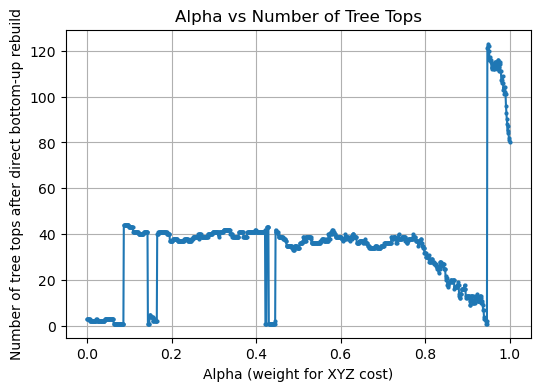

In [55]:
alpha_tree_tops_list = []
for i in range(1001):
    alpha = 0 + 0.001 * i
    alpha_tree_tops_list.append((alpha, pareto_list_direct_bottom_up_rebuild[i][4]))
# plot alpha vs tree tops
alphas = [x[0] for x in alpha_tree_tops_list]
tree_tops = [x[1] for x in alpha_tree_tops_list]
plt.figure(figsize=(6,4))
plt.plot(alphas, tree_tops, marker='o', markersize=2)
plt.xlabel('Alpha (weight for XYZ cost)')
plt.ylabel('Number of tree tops after direct bottom-up rebuild')
plt.title('Alpha vs Number of Tree Tops')
plt.grid(True)

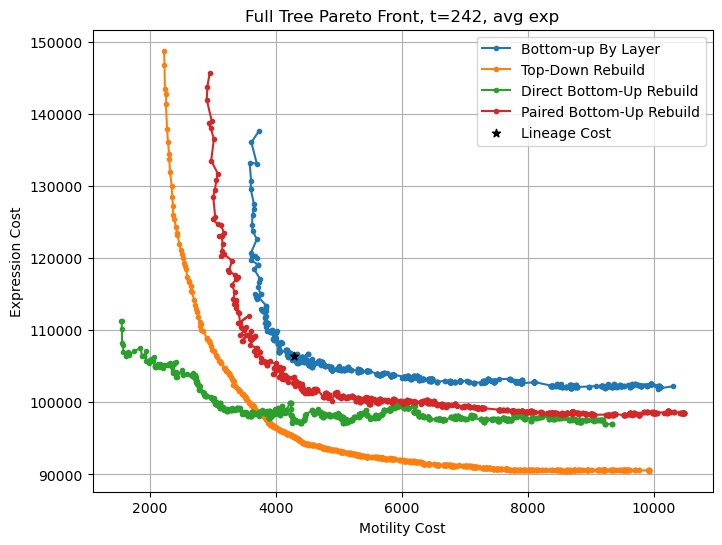

In [49]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_direct_bottom_up_rebuild = [cost[0] for cost in pareto_list_direct_bottom_up_rebuild]
pareto_exp_cost_list_direct_bottom_up_rebuild = [cost[1] for cost in pareto_list_direct_bottom_up_rebuild]
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Layer')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild')
plt.plot(pareto_xyz_cost_list_direct_bottom_up_rebuild, pareto_exp_cost_list_direct_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Direct Bottom-Up Rebuild')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Paired Bottom-Up Rebuild')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99)
plt.title(f'Full Tree Pareto Front, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [44]:
# save results to csv
import pandas as pd
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Top-Down Balanced Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_balanced_rebuild,
    'Top-Down Balanced Rebuild Exp Cost': pareto_exp_cost_list_top_down_balanced_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild
})
results_df.to_csv('output/internal_opt/s3_242_3d_l2/pareto_front.csv', index=False)

In [11]:
pareto_list_direct_bottom_up_rebuild = opt.direct_bottom_up_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [15]:
pareto_list_terminal_only = opt.terminal_only_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [10]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [56]:
# all tree bottom up by layer pareto optimization
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_by_cell = opt.bottom_up_by_cell_runner()


Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

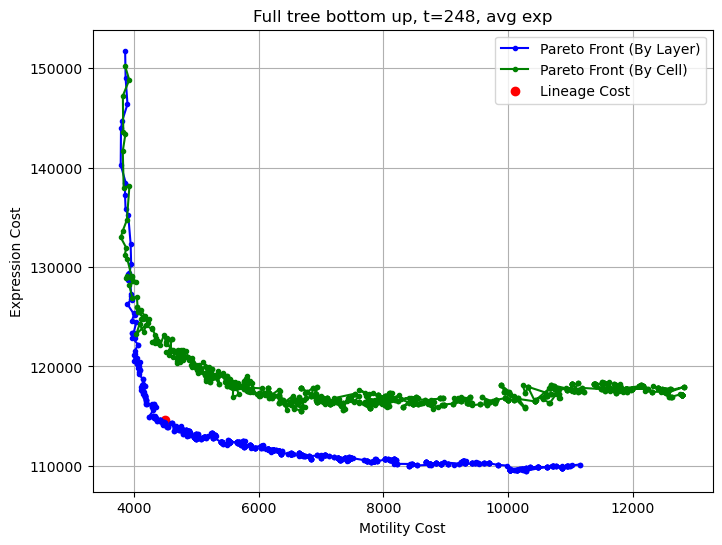

In [ ]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_by_cell = [cost[0] for cost in pareto_list_by_cell]
pareto_exp_cost_list_by_cell = [cost[1] for cost in pareto_list_by_cell]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='red', label='Lineage Cost')
plt.title(f'Full tree bottom up, t=248, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [58]:
first_layer_names = ['ABa', 'ABp', 'P2', 'EMS']
pareto_list_by_layer_subtree = []
pareto_list_by_cell_subtree = []
lineage_cost_subtree = []
for name, layer in zip(first_layer_names, first_layer):
    subtree_pareto_list_by_layer = opt.bottom_up_by_layer_runner(first_internal_layer=[layer])
    subtree_pareto_list_by_cell = opt.bottom_up_by_cell_runner(first_internal_layer=[layer])
    pareto_list_by_layer_subtree.append(subtree_pareto_list_by_layer)
    pareto_list_by_cell_subtree.append(subtree_pareto_list_by_cell)
    lineage_cost_subtree.append(opt.calc_lineage_cost(first_internal_tree_ids=[layer[0]]))

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [59]:
subtree_edge_counts = [360, 368, 184, 96]

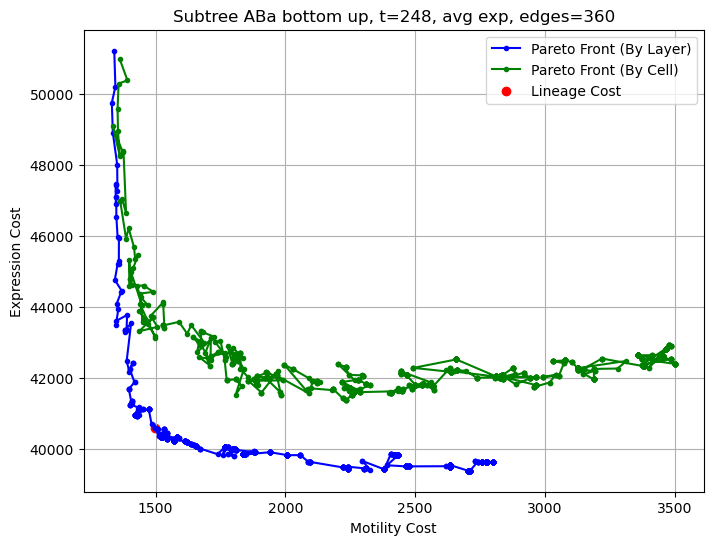

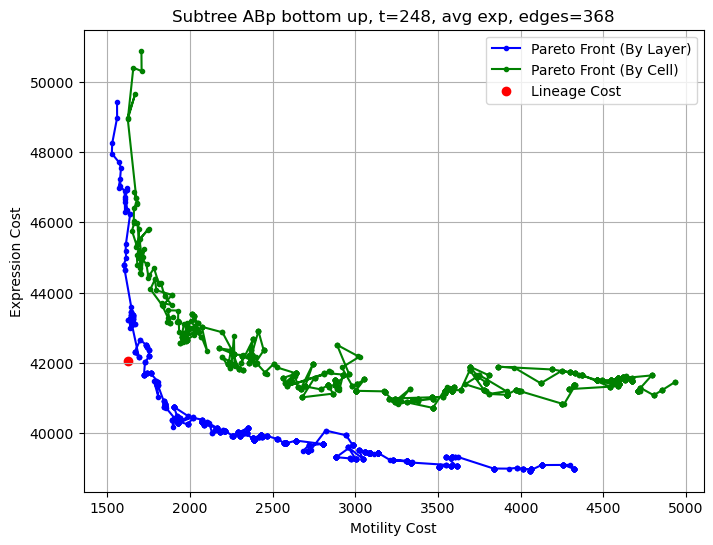

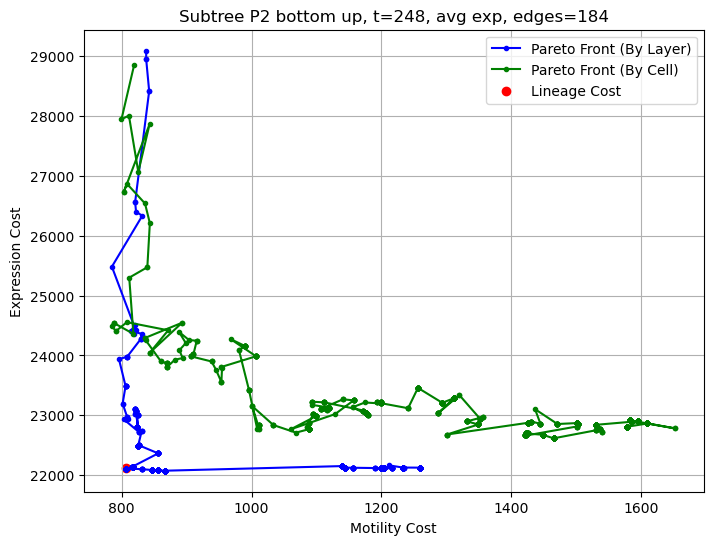

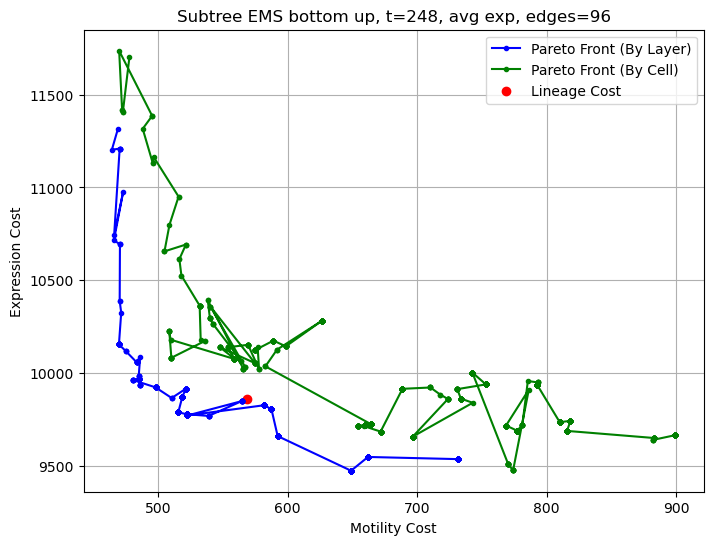

In [60]:
for edge_count, name, subtree_pareto_list_by_layer, subtree_pareto_list_by_cell, lineage_cost in \
        zip(subtree_edge_counts, first_layer_names, pareto_list_by_layer_subtree, pareto_list_by_cell_subtree, lineage_cost_subtree):
    pareto_xyz_cost_list_by_layer = [cost[0] for cost in subtree_pareto_list_by_layer]
    pareto_exp_cost_list_by_layer = [cost[1] for cost in subtree_pareto_list_by_layer]
    pareto_xyz_cost_list_by_cell = [cost[0] for cost in subtree_pareto_list_by_cell]
    pareto_exp_cost_list_by_cell = [cost[1] for cost in subtree_pareto_list_by_cell]
    plt.figure(figsize=(8, 6))
    plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
    plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
    plt.xlabel('Motility Cost')
    plt.ylabel('Expression Cost')
    plt.scatter(lineage_cost[0], lineage_cost[1], color='red', label='Lineage Cost')
    plt.title(f'Subtree {name} bottom up, t=248, avg exp, edges={edge_count}')
    plt.grid(True)
    plt.legend()
    plt.show()

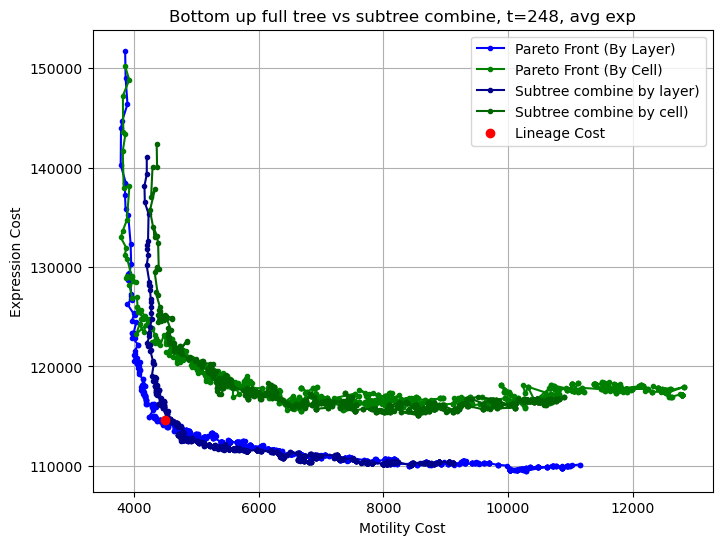

In [62]:
pareto_list_by_layer_subtree_sum = np.array(pareto_list_by_layer_subtree).sum(axis=0)
pareto_list_by_cell_subtree_sum = np.array(pareto_list_by_cell_subtree).sum(axis=0)

pareto_xyz_cost_list_by_layer_subtree_aggregate = [cost[0] for cost in pareto_list_by_layer_subtree_sum]
pareto_exp_cost_list_by_layer_subtree_aggregate = [cost[1] for cost in pareto_list_by_layer_subtree_sum]
pareto_xyz_cost_list_by_cell_subtree_aggregate = [cost[0] for cost in pareto_list_by_cell_subtree_sum]
pareto_exp_cost_list_by_cell_subtree_aggregate = [cost[1] for cost in pareto_list_by_cell_subtree_sum]
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_by_cell = [cost[0] for cost in pareto_list_by_cell]
pareto_exp_cost_list_by_cell = [cost[1] for cost in pareto_list_by_cell]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-', color='blue', markersize=3, label='Pareto Front (By Layer)')
plt.plot(pareto_xyz_cost_list_by_cell, pareto_exp_cost_list_by_cell, marker='o', linestyle='-', color='green', markersize=3, label='Pareto Front (By Cell)')
plt.plot(pareto_xyz_cost_list_by_layer_subtree_aggregate, pareto_exp_cost_list_by_layer_subtree_aggregate, marker='o', linestyle='-', color='darkblue', markersize=3, label='Subtree combine by layer)')
plt.plot(pareto_xyz_cost_list_by_cell_subtree_aggregate, pareto_exp_cost_list_by_cell_subtree_aggregate, marker='o', linestyle='-', color='darkgreen', markersize=3, label='Subtree combine by cell)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='red', label='Lineage Cost', zorder=5)
plt.title(f'Bottom up full tree vs subtree combine, t=248, avg exp')
plt.grid(True)
plt.legend()
plt.show()


In [55]:
pareto_list_by_layer

[(np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float64(9536.769914947768)),
 (np.float64(731.644894016134), np.float